In [ ]:
 !pip install geopandas pandas matplotlib contextily pysal requests

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.8/142.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.9/47.9 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.6/141.6 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.1/243.1 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━

In [ ]:
# Install required libraries (if necessary)
# !pip install geopandas pandas matplotlib contextily pysal requests

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx

import requests
import zipfile
import io

from esda.moran import Moran
from libpysal.weights import Queen

# Step 1: Get Census Tract Shapefile for Houston
url_tracts = 'https://www2.census.gov/geo/tiger/TIGER2023/TRACT/tl_2023_48201_tract.zip'
response = requests.get(url_tracts)
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    z.extractall('houston_tracts')

census_tracts = gpd.read_file('houston_tracts/tl_2023_48201_tract.shp')

# Step 2: Get Socioeconomic Data (Population density, Median Income)
acs_url = 'https://api.census.gov/data/2021/acs/acs5?get=B01003_001E,B19013_001E&for=tract:*&in=state:48%20county:201'
acs_data = requests.get(acs_url).json()
acs_df = pd.DataFrame(acs_data[1:], columns=['population', 'median_income', 'state', 'county', 'tract'])
acs_df['GEOID'] = acs_df['state'] + acs_df['county'] + acs_df['tract']
acs_df[['population', 'median_income']] = acs_df[['population', 'median_income']].astype(float)

# Merge ACS data with census tracts
census_tracts = census_tracts.merge(acs_df[['GEOID', 'population', 'median_income']], on='GEOID')

# Compute population density
census_tracts['area_sq_miles'] = census_tracts.geometry.to_crs({'proj':'aea'}).area / 2.59e+6
census_tracts['pop_density'] = census_tracts['population'] / census_tracts['area_sq_miles']

# Step 3: Load Air Quality Data (TCEQ stations)
aqi_url = 'https://opendata.arcgis.com/api/v3/datasets/ab6153d5c9644f9a9b505b2a14ae2df5_0/downloads/data?format=shp&spatialRefId=4326'
aqi_response = requests.get(aqi_url)
with zipfile.ZipFile(io.BytesIO(aqi_response.content)) as z:
    z.extractall('houston_aqi')

pollution = gpd.read_file('houston_aqi/Current_Air_Quality_Monitoring_Stations.shp').to_crs(census_tracts.crs)

# Step 4: Load Asthma Rates (example using synthetic data as placeholder)
# Replace with real data from Texas Department of State Health Services if available
census_tracts['asthma_rate'] = pd.Series(pd.np.random.uniform(5, 15, size=len(census_tracts)))

# Step 5: Visualize Population Density and Pollution Stations
ax = census_tracts.plot(column='pop_density', cmap='OrRd', legend=True, figsize=(10, 10), edgecolor='k')
ax.set_title('Population Density by Census Tract in Houston, TX')
ctx.add_basemap(ax, source=ctx.providers.Stamen.TonerLite, crs=census_tracts.crs.to_string())
plt.savefig('houston_population_density.png')
plt.show()

ax = pollution.plot(color='blue', markersize=50, alpha=0.7, figsize=(10, 10))
ax.set_title('Air Quality Monitoring Stations in Houston, TX')
ctx.add_basemap(ax, source=ctx.providers.Stamen.TonerLite, crs=pollution.crs.to_string())
plt.savefig('houston_pollution_stations.png')
plt.show()

# Step 6: Spatial Join - Aggregate Pollution to Census Tracts
census_tracts = gpd.sjoin_nearest(census_tracts, pollution[['geometry']], how='left', distance_col='pollution_distance')

# Compute Moran's I for spatial autocorrelation of population density
w = Queen.from_dataframe(census_tracts)
w.transform = 'r'
moran = Moran(census_tracts['pop_density'], w)
print(f"Moran's I: {moran.I:.3f}, p-value: {moran.p_norm:.4f}")

# Step 7: Prioritize Areas for Electrification
census_tracts['priority_score'] = (
    census_tracts['pop_density'] *
    (1 / census_tracts['median_income']) *
    census_tracts['asthma_rate']
)

# Plot Priority Areas
ax = census_tracts.plot(column='priority_score', cmap='Reds', legend=True, figsize=(10, 10), edgecolor='k')
ax.set_title('Priority Areas for Electrification in Houston, TX')
ctx.add_basemap(ax, source=ctx.providers.Stamen.TonerLite, crs=census_tracts.crs.to_string())
plt.savefig('houston_priority_areas.png')
plt.show()

BadZipFile: File is not a zip file

In [ ]:
!pip uninstall -y pysal esda spaghetti libpysal geopandas


Found existing installation: pysal 25.1
Uninstalling pysal-25.1:
  Successfully uninstalled pysal-25.1
Found existing installation: esda 2.7.0
Uninstalling esda-2.7.0:
  Successfully uninstalled esda-2.7.0
Found existing installation: spaghetti 1.7.6
Uninstalling spaghetti-1.7.6:
  Successfully uninstalled spaghetti-1.7.6
Found existing installation: libpysal 4.13.0
Uninstalling libpysal-4.13.0:
  Successfully uninstalled libpysal-4.13.0
Found existing installation: geopandas 1.0.1
Uninstalling geopandas-1.0.1:
  Successfully uninstalled geopandas-1.0.1


In [ ]:
!pip install --upgrade geopandas
!pip install --upgrade libpysal
!pip install --upgrade esda
!pip install --upgrade pysal


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.6/323.6 kB 4.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
momepy 0.9.1 requires libpysal>=4.12.0, which is not installed.
spopt 0.6.1 requires libpysal>=4.6, which is not installed.
spopt 0.6.1 requires spaghetti>=1.6.4, which is not installed.
pointpats 2.5.1 requires libpysal>=4.8, which is not installed.
splot 1.1.7 requires esda, which is not installed.
splot 1.1.7 requires libpysal, which is not installed.
tobler 0.12.1 requires libpysal, which is not installed.
segregation 2.5.2 requires libpysal, which is not installed.


  Using cached libpysal-4.13.0-py3-none-any.whl.metadata (4.8 kB)
Using cached libpysal-4.13.0-py3-none-any.whl (2.8 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
giddy 2.3.6 requires esda>=2.4, which is not installed.
spopt 0.6.1 requires spaghetti>=1.6.4, which is not installed.
splot 1.1.7 requires esda, which is not installed.


  Using cached esda-2.7.0-py3-none-any.whl.metadata (2.0 kB)
Using cached esda-2.7.0-py3-none-any.whl (142 kB)


  Using cached pysal-25.1-py3-none-any.whl.metadata (15 kB)
  Using cached spaghetti-1.7.6-py3-none-any.whl.metadata (12 kB)
Using cached pysal-25.1-py3-none-any.whl (17 kB)
Using cached spaghetti-1.7.6-py3-none-any.whl (53 kB)


In [ ]:
import requests
import zipfile
import io

url_tracts = 'https://www2.census.gov/geo/tiger/TIGER2022/TRACT/tl_2022_48201_tract.zip'
response = requests.get(url_tracts, stream=True)

if response.status_code == 200:
    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        z.extractall('houston_tracts')
    print("Download and extraction successful.")
else:
    print(f"Download failed with status code {response.status_code}")


Download failed with status code 404


In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx

# Load Census Tracts Shapefile
census_tracts = gpd.read_file('path_to_census_tracts_shapefile.shp')

# Load Population Density Data
population_density = pd.read_csv('path_to_population_density_data.csv')

# Merge Population Density Data with Census Tracts
census_tracts = census_tracts.merge(population_density, on='tract_id')

# Load Air Quality Monitoring Stations Data
air_quality_stations = gpd.read_file('path_to_air_quality_stations_shapefile.shp')


DataSourceError: path_to_census_tracts_shapefile.shp: No such file or directory

In [ ]:
import geopandas as gpd

# Load the Harris County boundary from the GIS Map Service
url = "https://services.arcgis.com/0L95CJ0VTaxqcmED/arcgis/rest/services/HCAD_Harris_County_Boundary/FeatureServer/0/query?where=1=1&outFields=*&outSR=4326&f=geojson"
harris_boundary = gpd.read_file(url)
harris_boundary.plot()


HTTPError: HTTP Error 400: Bad Request

<Axes: >

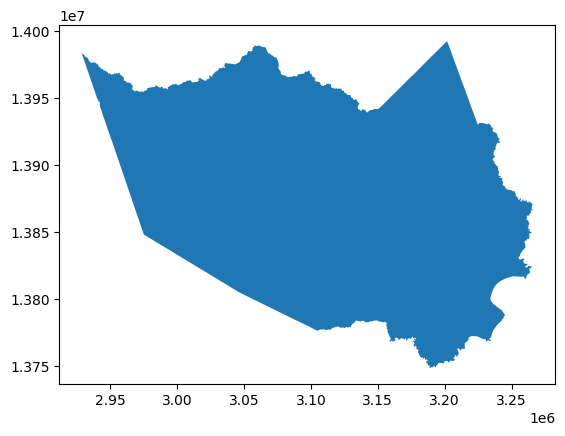

In [ ]:
import geopandas as gpd

county_boundary = gpd.read_file("County.shp")
county_boundary.plot()


In [ ]:
import geopandas as gpd

# TIGERweb Census Tracts for Harris County (FIPS: state=48, county=201)
tracts_url = "https://tigerweb.geo.census.gov/arcgis/rest/services/TIGERweb/Tracts_Blocks/MapServer/3/query?where=COUNTY='201'&outFields=GEOID&outSR=4326&f=geojson"

tracts = gpd.read_file(tracts_url)
tracts.plot(figsize=(10, 10))


URLError: <urlopen error [Errno 99] Cannot assign requested address>

In [ ]:
import pandas as pd

# API request for ACS 2021 5-year estimates: B01003 = total population, B19013 = median household income
acs_url = "https://api.census.gov/data/2021/acs/acs5?get=B01003_001E,B19013_001E&for=tract:*&in=state:48 county:201"

response = pd.read_json(acs_url)
df = pd.DataFrame(response[1:], columns=response[0])
df['GEOID'] = df['state'] + df['county'] + df['tract']
df[['population', 'median_income']] = df[['B01003_001E', 'B19013_001E']].astype(float)


InvalidURL: URL can't contain control characters. '/data/2021/acs/acs5?get=B01003_001E,B19013_001E&for=tract:*&in=state:48 county:201' (found at least ' ')

In [ ]:
tracts = tracts.merge(df[['GEOID', 'population', 'median_income']], on='GEOID')
tracts['pop_density'] = tracts['population'] / (tracts.geometry.area / 1e6)  # pop per km²


In [ ]:
import matplotlib.pyplot as plt
import contextily as ctx

ax = tracts.plot(column='pop_density', cmap='OrRd', legend=True, figsize=(12, 10), edgecolor='k')
ax.set_title('Population Density by Census Tract - Harris County')
ctx.add_basemap(ax, source=ctx.providers.Stamen.TonerLite, crs=tracts.crs.to_string())
plt.show()


In [ ]:
import censusdata

data = censusdata.download('acs5', 2021,
    censusdata.censusgeo([('state', '48'), ('county', '201'), ('tract', '*')]),
    ['B01003_001E', 'B19013_001E']
)

data.reset_index(inplace=True)
data['GEOID'] = data['index'].apply(lambda x: x.geo[2][1] + x.geo[3][1] + x.geo[4][1])


ModuleNotFoundError: No module named 'censusdata'

In [ ]:
!pip install censusdata

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for censusdata: filename=CensusData-1.15.post1-py3-none-any.whl size=28205744 sha256=dcdc5b24b4b0f7ce8e10b5fbea9cb3013cd44087a56a379fbb56c2883a6dad48
  Stored in directory: /root/.cache/pip/wheels/7c/5b/55/834c5472b44ab5688be29f6009667601fbc13f38cff9dd36e6
Successfully built censusdata
